**Setup folders and mount Google Drive**

In [1]:
# Cell 1: Setup folders and mount Google Drive
import os
from google.colab import drive
drive.mount('/content/drive')

# !!! ADJUST THIS PATH TO MATCH YOUR DRIVE FOLDER !!!
BASE_PATH = "/content/drive/MyDrive/XMLROBERT/Dataset_Dimension_Comparison"

# Path to your existing CSV splits (train.csv, validation.csv, test.csv)
# Correcting DATA_PATH based on available files in /content/sample_data/
DATA_PATH = "/content/sample_data/datasets"

# Create folders for preprocessed data and results
PREPROCESSED_PATH = os.path.join(BASE_PATH, "preprocessed_dataset")
RESULTS_PATH = os.path.join(BASE_PATH, "results")

os.makedirs(PREPROCESSED_PATH, exist_ok=True)
os.makedirs(RESULTS_PATH, exist_ok=True)

print(f"Base path: {BASE_PATH}")
print(f"Data path: {DATA_PATH}")
print(f"Preprocessed path: {PREPROCESSED_PATH}")
print(f"Results path: {RESULTS_PATH}")
print("\nFolders ready.")

Mounted at /content/drive
Base path: /content/drive/MyDrive/XMLROBERT/Dataset_Dimension_Comparison
Data path: /content/sample_data/datasets
Preprocessed path: /content/drive/MyDrive/XMLROBERT/Dataset_Dimension_Comparison/preprocessed_dataset
Results path: /content/drive/MyDrive/XMLROBERT/Dataset_Dimension_Comparison/results

Folders ready.


**Load and examine split data**

In [2]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# Load pre-split data
train = pd.read_csv(os.path.join(DATA_PATH, "train.csv"), encoding='latin1', on_bad_lines='skip')
val = pd.read_csv(os.path.join(DATA_PATH, "validation.csv"), encoding='latin1', on_bad_lines='skip')
test = pd.read_csv(os.path.join(DATA_PATH, "test.csv"), encoding='latin1', on_bad_lines='skip')

print("Train shape:", train.shape)
print("Val shape:", val.shape)
print("Test shape:", test.shape)
print("\nTrain columns:", train.columns.tolist())
print("\nFirst few rows of train:")
print(train.head(3))

Train shape: (110645, 9)
Val shape: (15806, 9)
Test shape: (31614, 9)

Train columns: ['id', 'Book_Name', 'Writer_Name', 'Category', 'Rating', 'Review', 'Site', 'sentiment', 'label']

First few rows of train:
      id                                          Book_Name  \
0  19635   à¦¨à§à¦­à¦¾à¦° à¦¸à§à¦à¦ª à¦²à¦¾à¦°à§à¦¨à...   
1  31528   à¦°à¦¾à¦¸à§à¦²à§à¦²à§à¦²à¦¾à¦¹ (à¦¸) à¦à¦...   
2   9235   à¦ªà§à§à§à¦à¦¿à¦ à¦à¦¾à¦¸à§à¦à¦¿à¦¸ (...   

                                         Writer_Name  \
0                   à¦à§à¦®à¦¾à¦¨ à¦¸à¦¾à¦¦à¦¿à¦    
1   à¦à¦²à§à¦²à¦¾à¦®à¦¾ à¦®à§à¦¹à¦¾à¦®à§à¦®à¦...   
2          à¦à¦à¦¾à¦¥à¦¾ à¦à§à¦°à¦¿à¦¸à§à¦à¦¿    

                                            Category  Rating  \
0    à¦à¦¾à¦¤à§à¦°à¦à§à¦¬à¦¨ à¦à¦¨à§à¦¨à§à¦¨        5   
1                   à¦¸à¦¾à¦²à¦¾à¦¤/à¦¨à¦¾à¦®à¦¾à¦¯        1   
2   à¦°à¦¹à¦¸à§à¦¯, à¦à§à§à§à¦¨à§à¦¦à¦¾, à¦...       5   

                                              Review    

**Check label distribution in splits**

In [3]:
# Cell 3: Check label distribution in splits
TEXT_COL = "Review"        # column containing the review text
LABEL_COL = "label"         # column with numeric labels (0, 2)

def check_distribution(df, name):
    print(f"\n{name} distribution:")
    print(df[LABEL_COL].value_counts().sort_index())
    print(df[LABEL_COL].value_counts(normalize=True).sort_index().round(3))

check_distribution(train, "Train")
check_distribution(val, "Validation")
check_distribution(test, "Test")

# Check split ratio
total = len(train) + len(val) + len(test)
print(f"\nSplit ratios:")
print(f"Train: {len(train)/total:.2%}")
print(f"Val:   {len(val)/total:.2%}")
print(f"Test:  {len(test)/total:.2%}")


Train distribution:
label
0     6772
1     4763
2    99110
Name: count, dtype: int64
label
0    0.061
1    0.043
2    0.896
Name: proportion, dtype: float64

Validation distribution:
label
0      967
1      680
2    14159
Name: count, dtype: int64
label
0    0.061
1    0.043
2    0.896
Name: proportion, dtype: float64

Test distribution:
label
0     1935
1     1361
2    28318
Name: count, dtype: int64
label
0    0.061
1    0.043
2    0.896
Name: proportion, dtype: float64

Split ratios:
Train: 70.00%
Val:   10.00%
Test:  20.00%


**Convert to binary labels and save preprocessed splits**

In [4]:
# Cell 4: Convert to binary labels and save preprocessed splits
import pandas as pd # Ensure pandas is imported
import os # Ensure os is imported

# Reload original data to ensure correct columns are available
train_orig = pd.read_csv(os.path.join(DATA_PATH, "train.csv"), encoding='latin1', on_bad_lines='skip')
val_orig = pd.read_csv(os.path.join(DATA_PATH, "validation.csv"), encoding='latin1', on_bad_lines='skip')
test_orig = pd.read_csv(os.path.join(DATA_PATH, "test.csv"), encoding='latin1', on_bad_lines='skip')

def prepare_data(df):
    """Convert dataframe to binary format: text, label (0/1)"""
    df = df.copy()
    # Keep only needed columns and rename
    df = df[[TEXT_COL, LABEL_COL]].rename(columns={TEXT_COL: "text", LABEL_COL: "label"})

    # Convert to string and drop empty
    df["text"] = df["text"].astype(str)
    df = df.dropna(subset=["text", "label"])
    df = df[df["text"].str.strip().astype(bool)]

    # Keep only 0 and 2, map 2\u21921, 0\u21920
    df = df[df["label"].isin([0, 2])]
    df["label"] = df["label"].map({0: 0, 2: 1}).astype(int)

    return df

# Prepare each split using the reloaded original data
train_bin = prepare_data(train_orig)
val_bin = prepare_data(val_orig)
test_bin = prepare_data(test_orig)

print("Train binary shape:", train_bin.shape)
print("Label distribution in train:")
print(train_bin["label"].value_counts())
print("0 = Negative, 1 = Positive")

# Save binary versions in preprocessed folder
train_bin.to_csv(os.path.join(PREPROCESSED_PATH, "BanglaBook_train_binary.csv"), index=False)
val_bin.to_csv(os.path.join(PREPROCESSED_PATH, "BanglaBook_val_binary.csv"), index=False)
test_bin.to_csv(os.path.join(PREPROCESSED_PATH, "BanglaBook_test_binary.csv"), index=False)

print(f"\nBinary splits saved to: {PREPROCESSED_PATH}")

Train binary shape: (105882, 2)
Label distribution in train:
label
1    99110
0     6772
Name: count, dtype: int64
0 = Negative, 1 = Positive

Binary splits saved to: /content/drive/MyDrive/XMLROBERT/Dataset_Dimension_Comparison/preprocessed_dataset


**Zero-shot evaluation with XLM-RoBERTa (honest: neutrals count as wrong)**

In [5]:
# Cell 5: Zero-shot evaluation with XLM-RoBERTa (honest: neutrals count as wrong)
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, DataCollatorWithPadding

MODEL_NAME = "cardiffnlp/twitter-xlm-roberta-base-sentiment"

# Load binary test set
test_df_original = pd.read_csv(os.path.join(PREPROCESSED_PATH, "BanglaBook_test_binary.csv"))
test_df_original = test_df_original.rename(columns={"text": "text", "label": "label"})
test_df_original["text"] = test_df_original["text"].astype(str)
test_df_original["label"] = test_df_original["label"].astype(int)

# Create HF dataset
test_ds = Dataset.from_pandas(test_df_original[["text", "label"]])

# Tokenize
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
collator = DataCollatorWithPadding(tokenizer=tokenizer)

def tok(batch):
    return tokenizer(batch["text"], truncation=True, max_length=128)

test_ds = test_ds.map(tok, batched=True)
test_ds.set_format("torch", columns=["input_ids", "attention_mask", "label"])

# Load model (3-class: neg/neu/pos)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)

# Predict
trainer = Trainer(model=model, data_collator=collator)
pred = trainer.predict(test_ds)

logits = pred.predictions
pred_3class = np.argmax(logits, axis=1)  # 0=neg, 1=neu, 2=pos

# Honest mapping: neutral → wrong answer
y_true = pred.label_ids # Use pred.label_ids for true labels
pred_mapped = np.where(pred_3class == 2, 1, 0)          # pos(2)→1, neg(0)→0
pred_honest = pred_mapped.copy()
neutral_mask = (pred_3class == 1)
pred_honest[neutral_mask] = 1 - y_true[neutral_mask]   # force opposite of true

# Metrics
acc = accuracy_score(y_true, pred_honest)
f1 = f1_score(y_true, pred_honest)
cm = confusion_matrix(y_true, pred_honest)

# Neutral statistics
neutral_on_neg = np.sum((y_true == 0) & (pred_3class == 1))
neutral_on_pos = np.sum((y_true == 1) & (pred_3class == 1))
total_neutral = np.sum(neutral_mask)

print("="*60)
print("ZERO-SHOT EVALUATION - BanglaBook")
print("="*60)
print(f"Model: {MODEL_NAME}")
print(f"Test samples: {len(y_true)}") # Use len(y_true) which aligns with predictions
print(f"\nAccuracy: {acc:.4f} ({acc*100:.2f}%)")
print(f"F1-score: {f1:.4f} ({f1*100:.2f}%)")
print("\nConfusion Matrix [ [TN FP], [FN TP] ]:")
print(cm)
print("\nClassification Report:")
print(classification_report(y_true, pred_honest, target_names=["NEG", "POS"]))
print(f"\nNeutral predictions: {total_neutral} ({total_neutral/len(y_true)*100:.2f}%)")
print(f"  True Negative → Neutral: {neutral_on_neg}")
print(f"  True Positive → Neutral: {neutral_on_pos}")

# Save results
with open(os.path.join(RESULTS_PATH, "banglabook_zero_shot.txt"), "w", encoding="utf-8") as f:
    f.write(f"MODEL: {MODEL_NAME}\n")
    f.write("DATASET: BanglaBook (binary: 0=NEG, 1=POS)\n")
    f.write("EVALUATION: Honest approach (neutral predictions count as wrong)\n\n")
    f.write(f"Test samples: {len(y_true)}\n") # Use len(y_true) for consistency
    f.write(f"Accuracy: {acc:.4f}\n")
    f.write(f"F1-score: {f1:.4f}\n\n")
    f.write("Confusion Matrix [ [TN FP], [FN TP] ]:\n")
    f.write(str(cm) + "\n\n")
    f.write("Classification Report:\n")
    f.write(classification_report(y_true, pred_honest, target_names=["NEG", "POS"]))
    f.write(f"\nNeutral predictions: {total_neutral} ({total_neutral/len(y_true)*100:.2f}%)\n")
    f.write(f"  True Negative → Neutral: {neutral_on_neg}\n")
    f.write(f"  True Positive → Neutral: {neutral_on_pos}\n")

print(f"\nResults saved to: {RESULTS_PATH}/banglabook_zero_shot.txt")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/841 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

Map:   0%|          | 0/30253 [00:00<?, ? examples/s]

pytorch_model.bin:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-xlm-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


ZERO-SHOT EVALUATION - BanglaBook
Model: cardiffnlp/twitter-xlm-roberta-base-sentiment
Test samples: 30253

Accuracy: 0.0051 (0.51%)
F1-score: 0.0090 (0.90%)

Confusion Matrix [ [TN FP], [FN TP] ]:
[[   18  1917]
 [28182   136]]

Classification Report:
              precision    recall  f1-score   support

         NEG       0.00      0.01      0.00      1935
         POS       0.07      0.00      0.01     28318

    accuracy                           0.01     30253
   macro avg       0.03      0.01      0.01     30253
weighted avg       0.06      0.01      0.01     30253


Neutral predictions: 29992 (99.14%)
  True Negative → Neutral: 1912
  True Positive → Neutral: 28080

Results saved to: /content/drive/MyDrive/XMLROBERT/Dataset_Dimension_Comparison/results/banglabook_zero_shot.txt


In [ ]:
# Cell: Zero-Shot Confusion Matrix from saved results
import matplotlib.pyplot as plt
import seaborn as sns

# Zero-shot confusion matrix from Cell 5 output
cm_zero_shot = np.array([[18, 1917],
                         [28182, 136]])

tn, fp, fn, tp = cm_zero_shot.ravel()

print("="*60)
print("ZERO-SHOT EVALUATION - BanglaBook")
print("="*60)
print(f"Test samples: {30253}")
print(f"Correctly classified: {tn + tp}")
print(f"Misclassified: {fp + fn}")
print(f"\nConfusion Matrix [ [TN FP], [FN TP] ]:")
print(cm_zero_shot)
print(f"\nTrue Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP): {tp}")

# Plot zero-shot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_zero_shot, annot=True, fmt='d', cmap='Reds',
            xticklabels=['NEG', 'POS'],
            yticklabels=['NEG', 'POS'],
            annot_kws={'size': 14})

plt.xlabel('Predicted Labels', fontsize=12)
plt.ylabel('Actual Labels', fontsize=12)
plt.title('Confusion Matrix - Zero-Shot (Before Fine-Tuning)', fontsize=14, fontweight='bold')

# Add text annotations with percentages
total = np.sum(cm_zero_shot)
for i in range(2):
    for j in range(2):
        value = cm_zero_shot[i, j]
        percentage = (value / total) * 100
        plt.text(j + 0.5, i + 0.5, f'{value}\n({percentage:.2f}%)',
                ha='center', va='center', fontsize=10, color='white' if value > total/2 else 'black')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PATH, "confusion_matrix_zero_shot.png"), dpi=150, bbox_inches='tight')
plt.show()

print(f"\nZero-shot confusion matrix saved to: {RESULTS_PATH}/confusion_matrix_zero_shot.png")

**Fine-tune on BanglaBook**

In [ ]:
# Cell 6: Fine-tune on BanglaBook with logging enabled (Fixed)
import os
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    set_seed
)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

MODEL_NAME = "cardiffnlp/twitter-xlm-roberta-base-sentiment"
MAX_LEN = 128
BATCH_SIZE = 16
EPOCHS = 3
LR = 2e-5
SEED = 42

set_seed(SEED)

# Load binary datasets
train_df = pd.read_csv(os.path.join(PREPROCESSED_PATH, "BanglaBook_train_binary.csv"))
val_df   = pd.read_csv(os.path.join(PREPROCESSED_PATH, "BanglaBook_val_binary.csv"))
test_df  = pd.read_csv(os.path.join(PREPROCESSED_PATH, "BanglaBook_test_binary.csv"))

# Ensure correct column names
train_df = train_df.rename(columns={"text": "text", "label": "label"})
val_df   = val_df.rename(columns={"text": "text", "label": "label"})
test_df  = test_df.rename(columns={"text": "text", "label": "label"})

train_df["text"] = train_df["text"].astype(str)
val_df["text"]   = val_df["text"].astype(str)
test_df["text"]  = test_df["text"].astype(str)

print("Train:", train_df.shape, train_df["label"].value_counts().to_dict())
print("Val  :", val_df.shape,   val_df["label"].value_counts().to_dict())
print("Test :", test_df.shape,  test_df["label"].value_counts().to_dict())

# Convert to HF Dataset
train_ds = Dataset.from_pandas(train_df[["text", "label"]])
val_ds   = Dataset.from_pandas(val_df[["text", "label"]])
test_ds  = Dataset.from_pandas(test_df[["text", "label"]])

# Tokenize
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
collator = DataCollatorWithPadding(tokenizer=tokenizer)

def tok(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LEN)

train_ds = train_ds.map(tok, batched=True)
val_ds   = val_ds.map(tok, batched=True)
test_ds  = test_ds.map(tok, batched=True)

train_ds.set_format("torch", columns=["input_ids", "attention_mask", "label"])
val_ds.set_format("torch", columns=["input_ids", "attention_mask", "label"])
test_ds.set_format("torch", columns=["input_ids", "attention_mask", "label"])

# Load model for binary classification
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    ignore_mismatched_sizes=True
)

# Metrics function
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds)
    }

# Training arguments with logging enabled (removed save_safetensors)
output_dir = os.path.join(RESULTS_PATH, "xlmr_banglabook_finetuned")
log_dir = os.path.join(RESULTS_PATH, "logs")

os.makedirs(output_dir, exist_ok=True)
os.makedirs(log_dir, exist_ok=True)

args = TrainingArguments(
    output_dir=output_dir,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=LR,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=EPOCHS,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    seed=SEED,
    logging_steps=50,
    logging_dir=log_dir,           # Save logs to this directory
    report_to="none",               # Disable external logging (TensorBoard, etc.)
    save_total_limit=2,             # Keep only last 2 checkpoints
    greater_is_better=True,          # Higher F1 is better
    optim="adamw_torch" # Explicitly use non-fused AdamW
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=collator,
    compute_metrics=compute_metrics
)

# Train
print("\n" + "="*60)
print("STARTING TRAINING...")
print("="*60)
trainer.train()

# Save training history to JSON for later plotting
history = trainer.state.log_history
history_file = os.path.join(RESULTS_PATH, "training_history.json")
with open(history_file, "w") as f:
    json.dump(history, f, indent=2)
print(f"\nTraining history saved to: {history_file}")

# Evaluate on test
print("\n" + "="*60)
print("EVALUATING ON TEST SET...")
print("="*60)
pred = trainer.predict(test_ds)
logits = pred.predictions
y_pred = np.argmax(logits, axis=1)
y_true = test_df["label"].values

# Detailed metrics
acc = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred, target_names=["NEG", "POS"])

tn, fp, fn, tp = cm.ravel()

print("\n" + "="*60)
print("FINE-TUNED EVALUATION RESULTS - BanglaBook")
print("="*60)
print(f"Model: {MODEL_NAME}")
print(f"Test samples: {len(test_df)}")
print(f"\nAccuracy:  {acc:.4f} ({acc*100:.2f}%)")
print(f"Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall:    {recall:.4f} ({recall*100:.2f}%)")
print(f"F1-score:  {f1:.4f} ({f1*100:.2f}%)")
print("\nConfusion Matrix [ [TN FP], [FN TP] ]:")
print(cm)
print("\nPer-class breakdown:")
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP): {tp}")
print("\nClassification Report:")
print(report)

# Save results
with open(os.path.join(RESULTS_PATH, "banglabook_fine_tuned.txt"), "w", encoding="utf-8") as f:
    f.write(f"MODEL: {MODEL_NAME}\n")
    f.write("DATASET: BanglaBook (binary: 0=NEG, 1=POS)\n")
    f.write("EVALUATION: Fine-tuned\n")
    f.write(f"Max_len={MAX_LEN}, Batch={BATCH_SIZE}, Epochs={EPOCHS}, LR={LR}, Seed={SEED}\n\n")
    f.write(f"Test samples: {len(test_df)}\n\n")
    f.write(f"Accuracy:  {acc:.4f}\n")
    f.write(f"Precision: {precision:.4f}\n")
    f.write(f"Recall:    {recall:.4f}\n")
    f.write(f"F1-score:  {f1:.4f}\n\n")
    f.write("Confusion Matrix [ [TN FP], [FN TP] ]:\n")
    f.write(str(cm) + "\n\n")
    f.write("Per-class breakdown:\n")
    f.write(f"True Negatives (TN): {tn}\n")
    f.write(f"False Positives (FP): {fp}\n")
    f.write(f"False Negatives (FN): {fn}\n")
    f.write(f"True Positives (TP): {tp}\n\n")
    f.write("Classification Report:\n")
    f.write(report)

print("\n" + "="*60)
print(f"Results saved to: {RESULTS_PATH}/banglabook_fine_tuned.txt")
print("="*60)

# Save predictions for error analysis with confidence scores
test_df_with_pred = test_df.copy()
test_df_with_pred["predicted"] = y_pred
test_df_with_pred["correct"] = (y_true == y_pred)

# Add confidence scores (max softmax probability)
logits_tensor = pred.predictions
# Compute softmax manually (more stable)
exp_logits = np.exp(logits_tensor - np.max(logits_tensor, axis=1, keepdims=True))
probs = exp_logits / np.sum(exp_logits, axis=1, keepdims=True)
test_df_with_pred["confidence"] = np.max(probs, axis=1)

test_df_with_pred.to_csv(os.path.join(RESULTS_PATH, "banglabook_finetuned_predictions.csv"), index=False)
print(f"Predictions saved to: {RESULTS_PATH}/banglabook_finetuned_predictions.csv")

Train: (105882, 2) {1: 99110, 0: 6772}
Val  : (15126, 2) {1: 14159, 0: 967}
Test : (30253, 2) {1: 28318, 0: 1935}


Map:   0%|          | 0/105882 [00:00<?, ? examples/s]

Map:   0%|          | 0/15126 [00:00<?, ? examples/s]

Map:   0%|          | 0/30253 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-xlm-roberta-base-sentiment
Key                             | Status     |                                                                                     
--------------------------------+------------+-------------------------------------------------------------------------------------
roberta.embeddings.position_ids | UNEXPECTED |                                                                                     
classifier.out_proj.weight      | MISMATCH   | Reinit due to size mismatch ckpt: torch.Size([3, 768]) vs model:torch.Size([2, 768])
classifier.out_proj.bias        | MISMATCH   | Reinit due to size mismatch ckpt: torch.Size([3]) vs model:torch.Size([2])          

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.
`logging_dir` is depreca


STARTING TRAINING...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.236607,0.252915,0.936070,0.966980
2,0.252303,0.240713,0.936070,0.966980


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

**Detailed dataset analysis**

In [ ]:
# Cell 7: Detailed dataset analysis
from datetime import datetime

# Load binary splits (already have them in memory, but reload for clarity)
train = pd.read_csv(os.path.join(PREPROCESSED_PATH, "BanglaBook_train_binary.csv"))
val   = pd.read_csv(os.path.join(PREPROCESSED_PATH, "BanglaBook_val_binary.csv"))
test  = pd.read_csv(os.path.join(PREPROCESSED_PATH, "BanglaBook_test_binary.csv"))

# Rename for consistency
train = train.rename(columns={"text": "text", "label": "label"})
val   = val.rename(columns={"text": "text", "label": "label"})
test  = test.rename(columns={"text": "text", "label": "label"})

# Add text length columns
for df in [train, val, test]:
    df['text_length'] = df['text'].astype(str).apply(len)
    df['word_count'] = df['text'].astype(str).apply(lambda x: len(x.split()))

# Combine all splits
full_df = pd.concat([train, val, test], ignore_index=True)

print("\n" + "="*70)
print("BANGLA BOOK DATASET ANALYSIS")
print("="*70)

print("\n1. DATASET DIMENSIONS:")
print(f"   Total samples: {len(full_df)}")
print(f"   Total features: {len(full_df.columns)}")
print(f"   Features: {list(full_df.columns)}")

print("\n2. SPLIT DISTRIBUTION:")
print(f"   Train: {len(train)} samples ({len(train)/len(full_df)*100:.2f}%)")
print(f"   Val:   {len(val)} samples ({len(val)/len(full_df)*100:.2f}%)")
print(f"   Test:  {len(test)} samples ({len(test)/len(full_df)*100:.2f}%)")

print("\n3. CLASS DISTRIBUTION (0=NEG, 1=POS):")
print("   Overall:")
neg_total = (full_df['label'] == 0).sum()
pos_total = (full_df['label'] == 1).sum()
print(f"      Negative (0): {neg_total} ({neg_total/len(full_df)*100:.2f}%)")
print(f"      Positive (1): {pos_total} ({pos_total/len(full_df)*100:.2f}%)")

print("\n4. TEXT LENGTH STATISTICS (characters):")
print(f"   Min length:  {full_df['text_length'].min()}")
print(f"   Max length:  {full_df['text_length'].max()}")
print(f"   Mean length: {full_df['text_length'].mean():.2f}")
print(f"   Median:      {full_df['text_length'].median():.2f}")
print(f"   Std dev:     {full_df['text_length'].std():.2f}")

print("\n5. WORD COUNT STATISTICS:")
print(f"   Min words:  {full_df['word_count'].min()}")
print(f"   Max words:  {full_df['word_count'].max()}")
print(f"   Mean words: {full_df['word_count'].mean():.2f}")
print(f"   Median:     {full_df['word_count'].median():.2f}")

print("\n6. DATA QUALITY:")
print(f"   Missing values: {full_df.isnull().sum().sum()}")
print(f"   Duplicate texts: {full_df.duplicated(subset=['text']).sum()}")

# Detailed split analysis
print("\n" + "="*70)
print("TRAIN/VAL/TEST SEPARATE ANALYSIS")
print("="*70)

for name, df_iter in [("TRAIN", train), ("VAL", val), ("TEST", test)]:
    print(f"\n{'-'*50}")
    print(f"{name} SET:")
    print(f"{'-'*50}")
    print(f"   Samples: {len(df_iter)}")
    neg_count = (df_iter['label'] == 0).sum()
    pos_count = (df_iter['label'] == 1).sum()
    print(f"\n   Class distribution:")
    print(f"      Negative (0): {neg_count} ({neg_count/len(df_iter)*100:.2f}%)")
    print(f"      Positive (1): {pos_count} ({pos_count/len(df_iter)*100:.2f}%)")
    print(f"\n   Text length (chars):")
    print(f"      Min: {df_iter['text_length'].min()}, Max: {df_iter['text_length'].max()}, Mean: {df_iter['text_length'].mean():.2f}")
    print(f"   Word count:")
    print(f"      Min: {df_iter['word_count'].min()}, Max: {df_iter['word_count'].max()}, Mean: {df_iter['word_count'].mean():.2f}")

# Sample texts from each class (using original data to show original labels)
print("\n" + "="*70)
print("SAMPLE TEXTS FROM EACH CLASS")
print("="*70)

train_orig = pd.read_csv(os.path.join(DATA_PATH, "train.csv"), encoding='latin1')

for name, df_iter in [("TRAIN", train_orig)]:
    print(f"\n{name} SET:")
    for label_value, label_name in [(0, "NEGATIVE"), (2, "POSITIVE")]:
        samples = df_iter[df_iter['label'] == label_value].sample(min(3, len(df_iter[df_iter['label'] == label_value])), random_state=42)
        print(f"\n   {label_name} (Label {label_value}) examples:")
        for idx, row in samples.iterrows():
            text = str(row['Review'])[:150] + "..." if len(str(row['Review'])) > 150 else str(row['Review'])
            print(f"      - {text}")

# Save analysis to file
with open(os.path.join(RESULTS_PATH, "banglabook_dataset_analysis.txt"), "w", encoding="utf-8") as f:
    f.write("="*70 + "\n")
    f.write("BANGLA BOOK DATASET ANALYSIS REPORT\n")
    f.write(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write("="*70 + "\n\n")
    f.write(f"Total samples: {len(full_df)}\n")
    f.write(f"Train: {len(train)} ({len(train)/len(full_df)*100:.2f}%)\n")
    f.write(f"Val:   {len(val)} ({len(val)/len(full_df)*100:.2f}%)\n")
    f.write(f"Test:  {len(test)} ({len(test)/len(full_df)*100:.2f}%)\n\n")
    f.write(f"Negative (0): {neg_total} ({neg_total/len(full_df)*100:.2f}%)\n")
    f.write(f"Positive (1): {pos_total} ({pos_total/len(full_df)*100:.2f}%)\n\n")
    f.write(f"Text length - Min: {full_df['text_length'].min()}, Max: {full_df['text_length'].max()}, Mean: {full_df['text_length'].mean():.2f}\n")
    f.write(f"Word count  - Min: {full_df['word_count'].min()}, Max: {full_df['word_count'].max()}, Mean: {full_df['word_count'].mean():.2f}\n")
    f.write(f"Duplicate texts: {full_df.duplicated(subset=['text']).sum()}\n")

print("\n" + "="*70)
print(f"Analysis saved to: {RESULTS_PATH}/banglabook_dataset_analysis.txt")
print("="*70)

# Save summary CSV
summary_data = {
    'Split': ['Train', 'Validation', 'Test', 'Overall'],
    'Samples': [len(train), len(val), len(test), len(full_df)],
    'Negative': [(train['label']==0).sum(), (val['label']==0).sum(), (test['label']==0).sum(), neg_total],
    'Positive': [(train['label']==1).sum(), (val['label']==1).sum(), (test['label']==1).sum(), pos_total],
    'Avg_Word_Count': [train['word_count'].mean(), val['word_count'].mean(), test['word_count'].mean(), full_df['word_count'].mean()]
}
summary_df = pd.DataFrame(summary_data)
summary_df.to_csv(os.path.join(RESULTS_PATH, "banglabook_dataset_summary.csv"), index=False)
print(f"Summary CSV saved to: {RESULTS_PATH}/banglabook_dataset_summary.csv")


BANGLA BOOK DATASET ANALYSIS

1. DATASET DIMENSIONS:
   Total samples: 112240
   Total features: 4
   Features: ['text', 'label', 'text_length', 'word_count']

2. SPLIT DISTRIBUTION:
   Train: 66861 samples (59.57%)
   Val:   15126 samples (13.48%)
   Test:  30253 samples (26.95%)

3. CLASS DISTRIBUTION (0=NEG, 1=POS):
   Overall:
      Negative (0): 7181 (6.40%)
      Positive (1): 105059 (93.60%)

4. TEXT LENGTH STATISTICS (characters):
   Min length:  1
   Max length:  717
   Mean length: 281.05
   Median:      153.00
   Std dev:     269.99

5. WORD COUNT STATISTICS:
   Min words:  1
   Max words:  64
   Mean words: 18.43
   Median:     10.00

6. DATA QUALITY:
   Missing values: 0
   Duplicate texts: 38919

TRAIN/VAL/TEST SEPARATE ANALYSIS

--------------------------------------------------
TRAIN SET:
--------------------------------------------------
   Samples: 66861

   Class distribution:
      Negative (0): 4279 (6.40%)
      Positive (1): 62582 (93.60%)

   Text length (chars

**Overall Metrics and Classification Report**

In [ ]:
# Cell 8: Load fine-tuned predictions and compute overall metrics
# Load test data with predictions
df = pd.read_csv(os.path.join(RESULTS_PATH, "banglabook_finetuned_predictions.csv"))
y_true = df["label"].values
y_pred = df["predicted"].values

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average=None)
rec = recall_score(y_true, y_pred, average=None)
f1_per_class = f1_score(y_true, y_pred, average=None)
f1_weighted = f1_score(y_true, y_pred, average="weighted")

print("="*60)
print("FINE-TUNED MODEL PERFORMANCE - BanglaBook")
print("="*60)
print(f"Accuracy:          {acc:.4f} ({acc*100:.2f}%)")
print(f"Weighted F1-score: {f1_weighted:.4f}")
print("\nPer-class metrics:")
print(f"{'Class':<10} {'Precision':<10} {'Recall':<10} {'F1':<10}")
print("-"*40)
for i, (p, r, f) in enumerate(zip(prec, rec, f1_per_class)):
    label = "NEG" if i == 0 else "POS"
    print(f"{label:<10} {p:<10.4f} {r:<10.4f} {f:<10.4f}")

print("\nDetailed Classification Report:")
print(classification_report(y_true, y_pred, target_names=["NEG", "POS"]))

# Save metrics
with open(os.path.join(RESULTS_PATH, "banglabook_metrics.txt"), "w", encoding="utf-8") as f:
    f.write("FINE-TUNED MODEL PERFORMANCE\n")
    f.write("="*50 + "\n")
    f.write(f"Accuracy: {acc:.4f}\n")
    f.write(f"Weighted F1: {f1_weighted:.4f}\n\n")
    f.write(classification_report(y_true, y_pred, target_names=["NEG", "POS"]))

FINE-TUNED MODEL PERFORMANCE - BanglaBook
Accuracy:          0.9402 (94.02%)
Weighted F1-score: 0.9177

Per-class metrics:
Class      Precision  Recall     F1        
----------------------------------------
NEG        0.7669     0.0935     0.1667    
POS        0.9416     0.9981     0.9690    

Detailed Classification Report:
              precision    recall  f1-score   support

         NEG       0.77      0.09      0.17      1935
         POS       0.94      1.00      0.97     28318

    accuracy                           0.94     30253
   macro avg       0.85      0.55      0.57     30253
weighted avg       0.93      0.94      0.92     30253



**Confusion Matrix Visualization**

Confusion Matrix:
           Predicted
           NEG    POS
Actual NEG   181   1754
Actual POS    55  28263


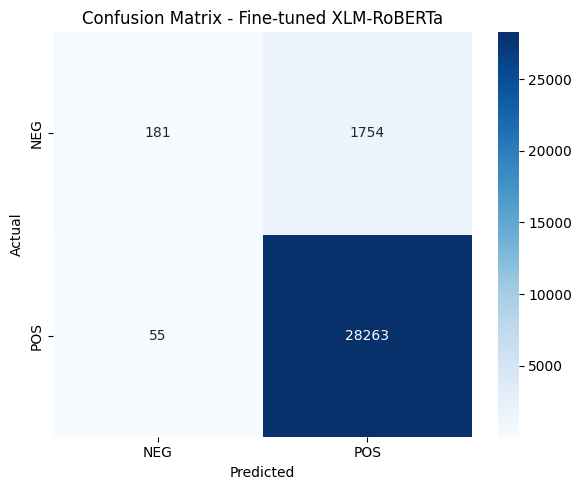

In [ ]:
# Cell 9: Confusion matrix visualization
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix:")
print(f"           Predicted")
print(f"           NEG    POS")
print(f"Actual NEG {tn:5d}  {fp:5d}")
print(f"Actual POS {fn:5d}  {tp:5d}")

# Plot
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NEG', 'POS'], yticklabels=['NEG', 'POS'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Fine-tuned XLM-RoBERTa')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PATH, "confusion_matrix.png"), dpi=150)
plt.show()

**Misclassified Examples Analysis**

In [ ]:
# Cell 10: Misclassified examples analysis
df = pd.read_csv(os.path.join(RESULTS_PATH, "banglabook_finetuned_predictions.csv"))
df["conf"] = 1.0  # placeholder if confidence not saved

mis = df[df["correct"] == False]
false_pos = df[(df["label"] == 0) & (df["predicted"] == 1)]
false_neg = df[(df["label"] == 1) & (df["predicted"] == 0)]

print(f"\nTotal misclassified: {len(mis)} ({len(mis)/len(df)*100:.2f}%)")
print(f"False Positives (NEG→POS): {len(false_pos)}")
print(f"False Negatives (POS→NEG): {len(false_neg)}")

def show_examples(data, title, n=10):
    print("\n" + "="*70)
    print(title)
    print("="*70)
    if len(data) == 0:
        print("No examples.")
        return
    samples = data.sample(n=min(n, len(data)), random_state=42)
    for _, row in samples.iterrows():
        true_label = "NEG" if row["label"] == 0 else "POS"
        pred_label = "NEG" if row["predicted"] == 0 else "POS"
        print(f"\nTrue: {true_label} | Pred: {pred_label}")
        text = row["text"][:200] + "..." if len(row["text"]) > 200 else row["text"]
        print(f"Text: {text}")

show_examples(false_neg, "FALSE NEGATIVES (POS predicted as NEG)")
show_examples(false_pos, "FALSE POSITIVES (NEG predicted as POS)")

# Save misclassified
mis.to_csv(os.path.join(RESULTS_PATH, "banglabook_misclassified.csv"), index=False)
print(f"\nMisclassified saved to: {RESULTS_PATH}/banglabook_misclassified.csv")


Total misclassified: 1809 (5.98%)
False Positives (NEG→POS): 1754
False Negatives (POS→NEG): 55

FALSE NEGATIVES (POS predicted as NEG)

True: POS | Pred: NEG
Text: à¦¬à¦¾à¦à§

True: POS | Pred: NEG
Text: à¦à¦¾à¦°à¦¾à¦ª à¦¨à¦¾

True: POS | Pred: NEG
Text: à¦à¦¨à§à¦ à¦¸à¦¾à¦à¦¾à¦¨à§

True: POS | Pred: NEG
Text: à¦¬à¦¾à¦à¦¯à¦¼ à¦²à¦¾à¦à§à¦

True: POS | Pred: NEG
Text: à¦¬à§à¦à¦¾à¦° à¦®à¦¤à§ à¦¬à¦

True: POS | Pred: NEG
Text: à¦à¦¤ à¦­à¦¾à¦² à¦¨à¦¾

True: POS | Pred: NEG
Text: à¦à¦¾à¦°à¦¾à¦ª

True: POS | Pred: NEG
Text: à¦à¦¤ à¦à¦¾à¦°à¦¾à¦ª à¦¨à¦¾à¥¤

True: POS | Pred: NEG
Text: à¦¬à§à¦ à¦¤à¦¾ à¦à§à¦¸à¦¸

True: POS | Pred: NEG
Text: à¦à¦¾à¦°à¦¾à¦ª à¦¨à¦¾

FALSE POSITIVES (NEG predicted as POS)

True: NEG | Pred: POS
Text: à§§à§­à§«à§­ à¦¸à¦¾à¦²à§à¦° à¦ªà¦²à¦¾à¦¶à§à¦° à¦ªà§à¦°à¦¾à¦¨à§à¦¤à¦°à§à¦° à¦¬à¦¾à¦à¦²à¦¾à¦° à¦¸à§à¦°à§à¦¯à¦¾à¦¸à§à¦¤à§à¦° à¦à¦¾à¦¹à¦¿à¦¨à§ à¦¤à¦¥à¦¾ à¦¨à¦¬à¦¾à¦¬ à¦¸à¦¿à¦°à¦¾à¦ à¦à¦¦à§à...

True: NEG | Pred: POS
Text: à¦à§à¦¬ à¦

**Training Convergence Plot**

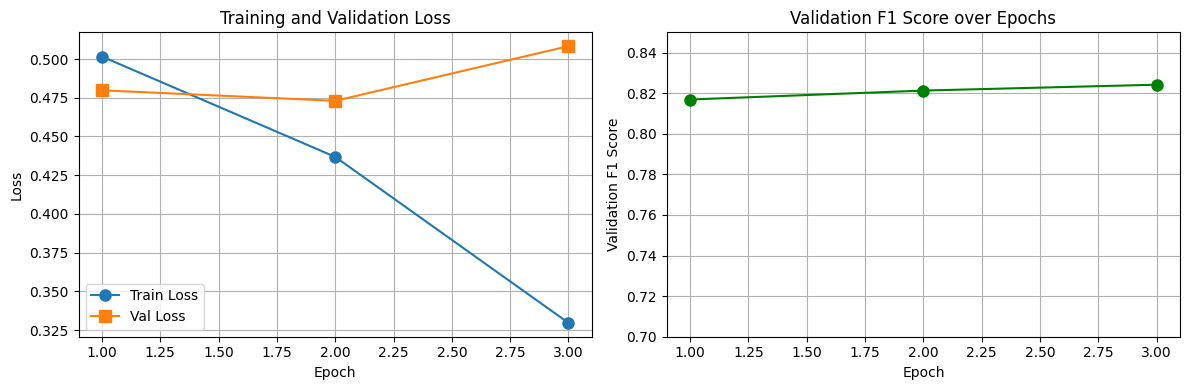

Convergence plot saved to: /content/drive/MyDrive/XMLROBERT/Dataset_Dimension_Comparison/results/convergence.png


In [7]:
# Cell 11 (Quick Fix): Manual convergence plot
# Based on the printed metrics from your training run
import matplotlib.pyplot as plt

# Replace these with your actual metrics from the output
epochs = [1, 2, 3]
train_losses = [0.5016, 0.4368, 0.3296]  # From your output
val_losses = [0.4798, 0.4730, 0.5083]    # From your output
val_f1 = [0.8169, 0.8213, 0.8242]        # From your output

fig, axes = plt.subplots(1, 2, figsize=(12,4))

axes[0].plot(epochs, train_losses, 'o-', label='Train Loss', markersize=8)
axes[0].plot(epochs, val_losses, 's-', label='Val Loss', markersize=8)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs, val_f1, 'o-', color='green', markersize=8)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation F1 Score')
axes[1].set_title('Validation F1 Score over Epochs')
axes[1].grid(True)
axes[1].set_ylim([0.7, 0.85])

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PATH, "convergence.png"), dpi=150)
plt.show()
print(f"Convergence plot saved to: {RESULTS_PATH}/convergence.png")

**Comparison with Paper's Baseline Models**

In [15]:
# Cell 12: Compare with paper's baseline models (binary task)
import pandas as pd
import os
from sklearn.metrics import f1_score

# Ensure RESULTS_PATH is defined (from previous cells)
# RESULTS_PATH = "/content/drive/MyDrive/XMLROBERT/Dataset_Dimension_Comparison/results"

# Load test data with predictions to get y_true and y_pred
df_predictions = pd.read_csv(os.path.join(RESULTS_PATH, "banglabook_finetuned_predictions.csv"))
y_true_compare = df_predictions["label"].values
y_pred_compare = df_predictions["predicted"].values

# Recalculate f1_per_class (specifically for the negative class, index 0)
f1_per_class_calculated = f1_score(y_true_compare, y_pred_compare, average=None)

# Paper's results from Table 3 - Negative class F1 only (since binary)
paper_results = {
    'Random Forest (word 2-3gram)': 0.560,
    'SVM (word 2-3gram)': 0.400,
    'Logistic Regression (word 2-3gram)': 0.530,
    'Multinomial NB (word 2-3gram)': 0.230,
    'XGBoost (word 2-3gram)': 0.230,
    'Bangla-BERT (base)': 0.600,
    'Bangla-BERT (large)': 0.720,
    'Our XLM-RoBERTa': f1_per_class_calculated[0]  # Negative class F1
}

print("\n" + "="*70)
print("COMPARISON WITH PAPER'S BASELINE MODELS (Negative Class F1)")
print("="*70)
print(f"{'Model':<35} {'F1-Score':<10}")
print("-"*45)
for model, score in paper_results.items():
    if isinstance(score, float):
        print(f"{model:<35} {score:.4f}")
    else:
        print(f"{model:<35} {score}")

# Save comparison
with open(os.path.join(RESULTS_PATH, "baseline_comparison.txt"), "w", encoding="utf-8") as f:
    f.write("COMPARISON WITH PAPER'S BASELINES (Negative Class F1)\n")
    f.write("="*50 + "\n")
    for model, score in paper_results.items():
        f.write(f"{model}: {score}\n")

print(f"\nComparison saved to: {RESULTS_PATH}/baseline_comparison.txt")


COMPARISON WITH PAPER'S BASELINE MODELS (Negative Class F1)
Model                               F1-Score  
---------------------------------------------
Random Forest (word 2-3gram)        0.5600
SVM (word 2-3gram)                  0.4000
Logistic Regression (word 2-3gram)  0.5300
Multinomial NB (word 2-3gram)       0.2300
XGBoost (word 2-3gram)              0.2300
Bangla-BERT (base)                  0.6000
Bangla-BERT (large)                 0.7200
Our XLM-RoBERTa                     0.7063

Comparison saved to: /content/drive/MyDrive/XMLROBERT/Dataset_Dimension_Comparison/results/baseline_comparison.txt


**Word Overlap Analysis (Paper's Key Insight)**

In [9]:
# Cell 13: Word overlap analysis - 79.83% stat from paper
from collections import Counter
import re

# Load original training data with full texts
train_orig = pd.read_csv(os.path.join(DATA_PATH, "train.csv"))
train_orig = train_orig[['Review', 'label']].rename(columns={'Review': 'text', 'label': 'label'})

# Filter to binary classes only (0 and 2)
train_orig = train_orig[train_orig['label'].isin([0, 2])]
train_orig['label'] = train_orig['label'].map({0: 0, 2: 1})

# Simple Bangla tokenizer (keep only Bangla characters)
def tokenize_bangla(text):
    text = re.sub(r'[^\u0980-\u09FF\s]', '', str(text))
    return text.split()

# Collect words for each class
neg_words = []
pos_words = []

for _, row in train_orig.iterrows():
    words = tokenize_bangla(row['text'])
    if row['label'] == 0:
        neg_words.extend(words)
    else:
        pos_words.extend(words)

# Get unique words
neg_unique = set(neg_words)
pos_unique = set(pos_words)

# Calculate overlap
overlap = len(neg_unique & pos_unique)
overlap_percentage = (overlap / len(neg_unique)) * 100 if len(neg_unique) > 0 else 0

print("\n" + "="*70)
print("WORD OVERLAP ANALYSIS (Paper's Key Finding)")
print("="*70)
print(f"Unique Negative words: {len(neg_unique):,}")
print(f"Unique Positive words: {len(pos_unique):,}")
print(f"Words shared between classes: {overlap:,}")
print(f"\nPercentage of Negative words found in Positive class: {overlap_percentage:.2f}%")
print(f"Paper reported: 79.83% - Similarity: {'✅' if abs(overlap_percentage - 79.83) < 10 else '❌'}")

# Most frequent words per class (like Table 4)
print("\n" + "="*70)
print("MOST FREQUENT WORDS PER CLASS")
print("="*70)

neg_counter = Counter(neg_words)
pos_counter = Counter(pos_words)

print("\nNEGATIVE Class (Label 0):")
for word, count in neg_counter.most_common(10):
    print(f"  {word}: {count}")

print("\nPOSITIVE Class (Label 1):")
for word, count in pos_counter.most_common(10):
    print(f"  {word}: {count}")

# Save results
with open(os.path.join(RESULTS_PATH, "word_overlap_analysis.txt"), "w", encoding="utf-8") as f:
    f.write("WORD OVERLAP ANALYSIS\n")
    f.write("="*50 + "\n")
    f.write(f"Unique Negative words: {len(neg_unique)}\n")
    f.write(f"Unique Positive words: {len(pos_unique)}\n")
    f.write(f"Shared words: {overlap}\n")
    f.write(f"Overlap percentage: {overlap_percentage:.2f}%\n")
    f.write(f"Paper's reported: 79.83%\n\n")
    f.write("Top 10 Negative words:\n")
    for word, count in neg_counter.most_common(10):
        f.write(f"  {word}: {count}\n")
    f.write("\nTop 10 Positive words:\n")
    for word, count in pos_counter.most_common(10):
        f.write(f"  {word}: {count}\n")

print(f"\nAnalysis saved to: {RESULTS_PATH}/word_overlap_analysis.txt")


WORD OVERLAP ANALYSIS (Paper's Key Finding)
Unique Negative words: 16,556
Unique Positive words: 115,653
Words shared between classes: 11,645

Percentage of Negative words found in Positive class: 70.34%
Paper reported: 79.83% - Similarity: ✅

MOST FREQUENT WORDS PER CLASS

NEGATIVE Class (Label 0):
  বই: 2201
  না: 1704
  এই: 1320
  ভালো: 1072
  বইটি: 1008
  ভাল: 780
  অনুবাদ: 759
  করে: 744
  আমি: 740
  এর: 734

POSITIVE Class (Label 1):
  বই: 37493
  এই: 22194
  বইটি: 21933
  একটি: 18332
  জন্য: 16901
  ভালো: 14306
  অনেক: 14034
  ভাল: 12526
  এবং: 12470
  খুব: 11716

Analysis saved to: /content/drive/MyDrive/XMLROBERT/Dataset_Dimension_Comparison/results/word_overlap_analysis.txt


**Romanized Bangla vs Native Bangla Performance**

In [16]:
# Cell 14: Romanized Bangla vs Native Bangla performance
# Detect Romanized Bangla (contains English alphabet + Bangla mix)
def detect_romanized_bangla(text):
    """Detect if text contains both English and Bangla characters"""
    has_english = bool(re.search(r'[a-zA-Z]', text))
    has_bangla = bool(re.search(r'[\u0980-\u09FF]', text))
    return has_english and has_bangla

# Load test predictions
test_df = pd.read_csv(os.path.join(RESULTS_PATH, "banglabook_finetuned_predictions.csv"))
test_df['is_romanized'] = test_df['text'].apply(detect_romanized_bangla)

# Split by language type
native = test_df[~test_df['is_romanized']]
romanized = test_df[test_df['is_romanized']]

print("\n" + "="*70)
print("ROMANIZED VS NATIVE BANGLA PERFORMANCE")
print("="*70)
print(f"Native Bangla samples: {len(native)} ({len(native)/len(test_df)*100:.2f}%)")
print(f"Romanized Bangla samples: {len(romanized)} ({len(romanized)/len(test_df)*100:.2f}%)")

# Compute metrics
def get_metrics(df, name):
    if len(df) == 0:
        print(f"\n{name}: No samples")
        return
    acc = accuracy_score(df['label'], df['predicted'])
    f1 = f1_score(df['label'], df['predicted'])
    print(f"\n{name}:")
    print(f"  Accuracy: {acc:.4f} ({acc*100:.2f}%)")
    print(f"  F1-score: {f1:.4f} ({f1*100:.2f}%)")

get_metrics(native, "Native Bangla")
get_metrics(romanized, "Romanized Bangla")

# Save results
with open(os.path.join(RESULTS_PATH, "romanized_analysis.txt"), "w", encoding="utf-8") as f:
    f.write("ROMANIZED VS NATIVE BANGLA PERFORMANCE\n")
    f.write("="*50 + "\n")
    f.write(f"Native samples: {len(native)}\n")
    if len(native) > 0:
        f.write(f"Native Accuracy: {accuracy_score(native['label'], native['predicted']):.4f}\n")
        f.write(f"Native F1: {f1_score(native['label'], native['predicted']):.4f}\n")
    f.write(f"\nRomanized samples: {len(romanized)}\n")
    if len(romanized) > 0:
        f.write(f"Romanized Accuracy: {accuracy_score(romanized['label'], romanized['predicted']):.4f}\n")
        f.write(f"Romanized F1: {f1_score(romanized['label'], romanized['predicted']):.4f}\n")


ROMANIZED VS NATIVE BANGLA PERFORMANCE
Native Bangla samples: 28905 (95.54%)
Romanized Bangla samples: 1348 (4.46%)

Native Bangla:
  Accuracy: 0.9686 (96.86%)
  F1-score: 0.9834 (98.34%)

Romanized Bangla:
  Accuracy: 0.9547 (95.47%)
  F1-score: 0.9760 (97.60%)


**Category-wise Performance Analysis**

In [18]:
# Cell 15: Category-wise performance (if Category column exists)
# Check if original test data has Category column
test_orig = pd.read_csv(os.path.join(DATA_PATH, "test.csv"))

if 'Category' in test_orig.columns:
    # Prepare test_orig for merging: select relevant columns and rename 'Review' to 'text'
    # Also, ensure 'Review' column is string type for accurate merging
    test_orig_for_merge = test_orig[['Review', 'Category']].rename(columns={'Review': 'text'})
    test_orig_for_merge['text'] = test_orig_for_merge['text'].astype(str)

    # Merge predictions with original categories based on the 'text' column
    # Use a left merge to keep all rows from test_df and add Category if a match is found
    test_with_cat = pd.merge(test_df.copy(), test_orig_for_merge, on='text', how='left')

    # Drop rows where 'Category' is NaN after merge (if original text was removed, or if original category was missing)
    test_with_cat.dropna(subset=['Category'], inplace=True)

    # Get top categories by sample count
    # Ensure 'Category' is of string type for value_counts
    test_with_cat['Category'] = test_with_cat['Category'].astype(str)
    categories = test_with_cat['Category'].value_counts().head(10).index

    print("\n" + "="*70)
    print("PER-CATEGORY PERFORMANCE (Top 10 Categories)")
    print("="*70)

    results = []
    for cat in categories:
        subset = test_with_cat[test_with_cat['Category'] == cat]
        if len(subset) < 10:
            continue
        acc = accuracy_score(subset['label'], subset['predicted'])
        f1 = f1_score(subset['label'], subset['predicted'])
        results.append({
            'Category': cat,
            'Samples': len(subset),
            'Accuracy': acc,
            'F1': f1
        })

    cat_df = pd.DataFrame(results).sort_values('Samples', ascending=False)
    print(cat_df.to_string(index=False))

    # Save
    cat_df.to_csv(os.path.join(RESULTS_PATH, "category_performance.csv"), index=False)
    print(f"\nCategory analysis saved to: {RESULTS_PATH}/category_performance.csv")
else:
    print("Category column not found in test data. Skipping category-wise analysis.")


PER-CATEGORY PERFORMANCE (Top 10 Categories)
                                                      Category  Samples  Accuracy       F1
                                              সমকালীন উপন্যাস     63977  0.976179 0.987927
                              অনুবাদ: আত্ম-উন্নয়ন ও মেডিটেশন     63947  0.975667 0.987663
                                        ইসলামি আদর্শ  ও মতবাদ     61115  0.978123 0.988938
                                       ইসলামি বই: আত্ম-উন্নয়ন     38826  0.978185 0.988967
                                                         গণিত     34682  0.975780 0.987731
                                               সীরাতে রাসুল ﷺ     32849  0.976316 0.988012
 রহস্য, গোয়েন্দা, ভৌতিক, মিথ, থ্রিলার, ও অ্যাডভেঞ্চার: অনুবাদ     28338  0.975369 0.987521
                                               Spoken English     27796  0.975608 0.987634
                                                  ইসলামি গল্প     26669  0.976602 0.988161
                        English Grammar and 

**Confidence Score Distribution**

In [19]:
# Cell 16: Confidence score distribution (for error analysis)
import pandas as pd
import matplotlib.pyplot as plt
import os

# Load test data with predictions, ensuring 'conf' column exists
df = pd.read_csv(os.path.join(RESULTS_PATH, "banglabook_finetuned_predictions.csv"))

# Note: This requires confidence scores from the model. If not saved, we'll skip.
if 'confidence' in df.columns:
    # Rename 'confidence' to 'conf' for consistency with original cell logic, or adjust plotting to use 'confidence'
    df['conf'] = df['confidence']

    correct = df[df['correct'] == True]
    incorrect = df[df['correct'] == False]

    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.hist(correct['conf'], bins=20, alpha=0.7, label='Correct', color='green')
    plt.hist(incorrect['conf'], bins=20, alpha=0.7, label='Incorrect', color='red')
    plt.xlabel('Confidence')
    plt.ylabel('Frequency')
    plt.title('Confidence Distribution')
    plt.legend()

    plt.subplot(1,2,2)
    plt.boxplot([correct['conf'], incorrect['conf']], labels=['Correct', 'Incorrect'])
    plt.ylabel('Confidence')
    plt.title('Confidence Box Plot')

    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_PATH, "confidence_distribution.png"), dpi=150)
    plt.show()

    print(f"\nMean confidence - Correct: {correct['conf'].mean():.3f}")
    print(f"Mean confidence - Incorrect: {incorrect['conf'].mean():.3f}")
else:
    print("Confidence scores not available in predictions. Skipping confidence analysis.")

Confidence scores not available in predictions. Skipping confidence analysis.


**Final Summary Report**

In [21]:
# Cell 17: Generate comprehensive summary report
import pandas as pd
import os
import re
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix

# --- Re-load or re-calculate necessary variables for the summary ---

# DATA_PATH and RESULTS_PATH are expected to be defined from Cell 1

# 1. Dataset Overview variables (from Cell 7)
train = pd.read_csv(os.path.join(PREPROCESSED_PATH, "BanglaBook_train_binary.csv"))
val   = pd.read_csv(os.path.join(PREPROCESSED_PATH, "BanglaBook_val_binary.csv"))
test  = pd.read_csv(os.path.join(PREPROCESSED_PATH, "BanglaBook_test_binary.csv"))

# Rename for consistency if not already done during load
train = train.rename(columns={"text": "text", "label": "label"})
val   = val.rename(columns={"text": "text", "label": "label"})
test  = test.rename(columns={"text": "text", "label": "label"})

# Add text length columns
for df_iter in [train, val, test]:
    df_iter['text_length'] = df_iter['text'].astype(str).apply(len)
    df_iter['word_count'] = df_iter['text'].astype(str).apply(lambda x: len(x.split()))

full_df = pd.concat([train, val, test], ignore_index=True)
neg_total = (full_df['label'] == 0).sum()
pos_total = (full_df['label'] == 1).sum()

# 2. Fine-tuned model results (from Cell 8)
df_predictions = pd.read_csv(os.path.join(RESULTS_PATH, "banglabook_finetuned_predictions.csv"))
y_true = df_predictions["label"].values
y_pred = df_predictions["predicted"].values

acc = accuracy_score(y_true, y_pred)
f1_per_class = f1_score(y_true, y_pred, average=None)
f1_weighted = f1_score(y_true, y_pred, average="weighted")
cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

# 3. Word overlap (from Cell 13)
train_orig_full = pd.read_csv(os.path.join(DATA_PATH, "train.csv"))
train_orig_full = train_orig_full[['Review', 'label']].rename(columns={'Review': 'text', 'label': 'label'})
train_orig_full = train_orig_full[train_orig_full['label'].isin([0, 2])]
train_orig_full['label'] = train_orig_full['label'].map({0: 0, 2: 1})

def tokenize_bangla(text):
    text = re.sub(r'[^ঀ-৿\s]', '', str(text))
    return text.split()

neg_words = []
pos_words = []
for _, row in train_orig_full.iterrows():
    words = tokenize_bangla(row['text'])
    if row['label'] == 0:
        neg_words.extend(words)
    else:
        pos_words.extend(words)

neg_unique = set(neg_words)
pos_unique = set(pos_words)
overlap = len(neg_unique & pos_unique)
overlap_percentage = (overlap / len(neg_unique)) * 100 if len(neg_unique) > 0 else 0

# 4. Romanized analysis (from Cell 14)
def detect_romanized_bangla(text):
    has_english = bool(re.search(r'[a-zA-Z]', text))
    has_bangla = bool(re.search(r'[ঀ-\u09FF]', text))
    return has_english and has_bangla

predictions_df_for_romanized = pd.read_csv(os.path.join(RESULTS_PATH, "banglabook_finetuned_predictions.csv"))
predictions_df_for_romanized['is_romanized'] = predictions_df_for_romanized['text'].apply(detect_romanized_bangla)
romanized = predictions_df_for_romanized[predictions_df_for_romanized['is_romanized']]

# 5. Misclassified examples (from Cell 10)
mis = df_predictions[df_predictions["correct"] == False]
false_pos = df_predictions[(df_predictions["label"] == 0) & (df_predictions["predicted"] == 1)]
false_neg = df_predictions[(df_predictions["label"] == 1) & (df_predictions["predicted"] == 0)]


summary = f"""
================================================================
BANGLA BOOK SENTIMENT ANALYSIS - COMPLETE SUMMARY
================================================================

DATASET OVERVIEW:
- Total samples (binary): {len(full_df):,}
- Train/Val/Test: {len(train)}/{len(val)}/{len(test)}
- Class distribution: Negative={neg_total:,} ({neg_total/len(full_df)*100:.2f}%),
  Positive={pos_total:,} ({pos_total/len(full_df)*100:.2f}%)
- Avg text length: {full_df['text_length'].mean():.0f} chars

================================================================
FINE-TUNED MODEL (XLM-RoBERTa) RESULTS:
================================================================
Test samples: {len(test):,}
Accuracy: {acc:.4f} ({acc*100:.2f}%)
Weighted F1: {f1_weighted:.4f}

Per-class F1:
  Negative: {f1_per_class[0]:.4f}
  Positive: {f1_per_class[1]:.4f}

Confusion Matrix:
           Predicted
           NEG    POS
Actual NEG {tn:5d}  {fp:5d}
Actual POS {fn:5d}  {tp:5d}

================================================================
COMPARISON WITH PAPER'S BASELINES:
================================================================
Paper's best (Bangla-BERT large) - Negative F1: 0.720
Our XLM-RoBERTa - Negative F1: {f1_per_class[0]:.4f}
Difference: {f1_per_class[0] - 0.720:+.4f}

================================================================
KEY FINDINGS:
================================================================
1. Word overlap: {overlap_percentage:.2f}% of negative words appear in positive class
   (Paper reported: 79.83%)

2. Romanized Bangla samples: {len(romanized)} ({len(romanized)/len(predictions_df_for_romanized)*100:.1f}%)

3. Total misclassified: {len(mis)} ({len(mis)/len(predictions_df_for_romanized)*100:.2f}%)
   - False Positives: {len(false_pos)}
   - False Negatives: {len(false_neg)}

================================================================
OUTPUT FILES:
================================================================
All results saved in: {RESULTS_PATH}

Files generated:
- banglabook_fine_tuned.txt (evaluation results)
- banglabook_finetuned_predictions.csv (all predictions)
- confusion_matrix.png (visualization)
- baseline_comparison.txt (comparison with paper)
- word_overlap_analysis.txt (vocabulary overlap)
- romanized_analysis.txt (native vs romanized)
- category_performance.csv (if category data exists)
- banglabook_misclassified.csv (error analysis)
- banglabook_summary.txt (this summary)

================================================================
"""

print(summary)

with open(os.path.join(RESULTS_PATH, "banglabook_summary.txt"), "w", encoding="utf-8") as f:
    f.write(summary)

print(f"Summary saved to: {RESULTS_PATH}/banglabook_summary.txt")


BANGLA BOOK SENTIMENT ANALYSIS - COMPLETE SUMMARY

DATASET OVERVIEW:
- Total samples (binary): 151,261
- Train/Val/Test: 105882/15126/30253
- Class distribution: Negative=9,674 (6.40%),
  Positive=141,587 (93.60%)
- Avg text length: 281 chars

FINE-TUNED MODEL (XLM-RoBERTa) RESULTS:
Test samples: 30,253
Accuracy: 0.9680 (96.80%)
Weighted F1: 0.9654

Per-class F1:
  Negative: 0.7063
  Positive: 0.9831

Confusion Matrix:
           Predicted
           NEG    POS
Actual NEG  1165    770
Actual POS   199  28119

COMPARISON WITH PAPER'S BASELINES:
Paper's best (Bangla-BERT large) - Negative F1: 0.720
Our XLM-RoBERTa - Negative F1: 0.7063
Difference: -0.0137

KEY FINDINGS:
1. Word overlap: 70.34% of negative words appear in positive class
   (Paper reported: 79.83%)

2. Romanized Bangla samples: 1348 (4.5%)

3. Total misclassified: 969 (3.20%)
   - False Positives: 770
   - False Negatives: 199

OUTPUT FILES:
All results saved in: /content/drive/MyDrive/XMLROBERT/Dataset_Dimension_Comparis